# ES Historical Data Analysis

Generated on 2025-09-28 16:11:11

## Overview
This notebook contains customized analysis for ES historical data.
The data has been automatically loaded and selected analysis features are ready to run.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [5]:
csv_path = '..\data\ES_data.csv'
symbol = 'ES'

print(f'📊 Loading data for {symbol}...')

# Read CSV with proper parsing
try:
    df_raw = pd.read_csv(csv_path)
    print(f'✅ Raw data loaded: {len(df_raw)} rows')
except Exception as e:
    print(f'❌ Error loading CSV: {e}')
    raise

# Clean and prepare time series data
def clean_financial_data(df):
    """Clean and prepare financial time series data"""
    df_clean = df.copy()
    
    # Handle date column (multiple possible formats)
    date_columns = ['date', 'Date', 'datetime', 'timestamp', 'time']
    date_col = None
    
    for col in date_columns:
        if col in df_clean.columns:
            date_col = col
            break
    
    if date_col:
        # Convert to datetime with multiple format handling
        try:
            df_clean[date_col] = pd.to_datetime(df_clean[date_col], utc=True)
            # Convert to local timezone if needed
            df_clean[date_col] = df_clean[date_col].dt.tz_convert(None)
        except:
            # Fallback to infer_datetime_format
            df_clean[date_col] = pd.to_datetime(df_clean[date_col], infer_datetime_format=True)
        
        # Set as index
        df_clean.set_index(date_col, inplace=True)
        df_clean.index.name = 'date'
    else:
        print('⚠️  No date column found - using row index')
    
    # Standardize column names (lowercase)
    df_clean.columns = df_clean.columns.str.lower()
    
    # Ensure numeric columns are properly typed
    numeric_cols = ['open', 'high', 'low', 'close', 'volume']
    for col in numeric_cols:
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    
    # Remove any rows with all NaN values
    df_clean.dropna(how='all', inplace=True)
    
    # Sort by date index
    if isinstance(df_clean.index, pd.DatetimeIndex):
        df_clean.sort_index(inplace=True)
    
    # Remove duplicate timestamps
    df_clean = df_clean[~df_clean.index.duplicated(keep='first')]
    
    return df_clean

# Clean the data
df = clean_financial_data(df_raw)

# Data quality checks
print('\n📋 Data Quality Report:')
print(f'   Rows after cleaning: {len(df)}')
print(f'   Columns: {list(df.columns)}')

if isinstance(df.index, pd.DatetimeIndex):
    print(f'   Date range: {df.index.min().strftime("%Y-%m-%d")} to {df.index.max().strftime("%Y-%m-%d")}')
    print(f'   Frequency: {pd.infer_freq(df.index) or "Irregular"}')

# Check for missing values
missing_data = df.isnull().sum()
if missing_data.sum() > 0:
    print('\n⚠️  Missing values detected:')
    for col, count in missing_data[missing_data > 0].items():
        print(f'   {col}: {count} missing ({count/len(df)*100:.1f}%)')
else:
    print('   ✅ No missing values')

# Display sample data
print('\n📊 Sample Data:')
display(df.head())

print('\n📈 Data Statistics:')
display(df.describe())

📊 Loading data for ES...
✅ Raw data loaded: 248 rows

📋 Data Quality Report:
   Rows after cleaning: 248
   Columns: ['open', 'high', 'low', 'close', 'volume']
   Date range: 2024-09-27 to 2025-09-26
   Frequency: Irregular
   ✅ No missing values

📊 Sample Data:


,open,high,low,close,volume
date,,,,,
2024-09-27,5956.50,5956.50,5956.50,5956.50,0.0
2024-09-30,5986.00,5986.00,5986.00,5986.00,0.0
2024-10-01,5930.50,5930.50,5930.50,5930.50,0.0
2024-10-02,5931.25,5931.25,5931.25,5931.25,0.0
2024-10-03,5922.25,5922.25,5922.25,5922.25,0.0



📈 Data Statistics:


,open,high,low,close,volume
count,248.000000,248.000000,248.000000,248.000000,2.480000e+02
mean,6141.454637,6157.228831,6126.009073,6143.941532,4.291964e+04
std,310.431291,300.949407,318.408416,309.304277,2.111487e+05
min,5007.500000,5315.000000,4970.000000,5091.000000,0.000000e+00
25%,5998.437500,6002.625000,5984.437500,5999.187500,0.000000e+00
50%,6168.000000,6169.250000,6166.875000,6169.250000,5.000000e+00
75%,6332.750000,6336.875000,6322.500000,6327.250000,2.077500e+02
max,6750.250000,6756.750000,6705.750000,6749.750000,1.440581e+06


In [3]:
# Basic data information
print('=== Data Information ===')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print('\n=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Basic Statistics ===')
df.describe()

=== Data Information ===
Shape: (248, 5)
Columns: ['open', 'high', 'low', 'close', 'volume']

=== Data Types ===
open      float64
high      float64
low       float64
close     float64
volume    float64
dtype: object

=== Missing Values ===
open      0
high      0
low       0
close     0
volume    0
dtype: int64

=== Basic Statistics ===


,open,high,low,close,volume
count,248.000000,248.000000,248.000000,248.000000,2.480000e+02
mean,6141.454637,6157.228831,6126.009073,6143.941532,4.291964e+04
std,310.431291,300.949407,318.408416,309.304277,2.111487e+05
min,5007.500000,5315.000000,4970.000000,5091.000000,0.000000e+00
25%,5998.437500,6002.625000,5984.437500,5999.187500,0.000000e+00
50%,6168.000000,6169.250000,6166.875000,6169.250000,5.000000e+00
75%,6332.750000,6336.875000,6322.500000,6327.250000,2.077500e+02
max,6750.250000,6756.750000,6705.750000,6749.750000,1.440581e+06


NameError: name 'mdates' is not defined

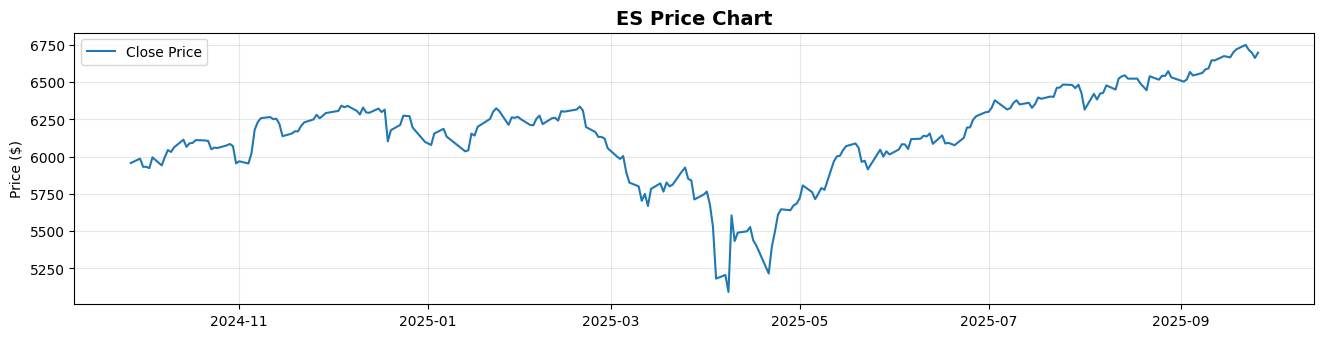

In [4]:
# Professional financial time series visualization
def create_financial_charts(df, symbol):
    """Create comprehensive financial charts"""
    
    has_close = 'close' in df.columns
    has_volume = 'volume' in df.columns
    
    if not has_close:
        print('❌ No close price data available')
        return
    
    # Create figure with subplots
    fig = plt.figure(figsize=(16, 12))
    
    # Price chart
    ax1 = plt.subplot(3, 2, (1, 2))  # Top row, full width
    ax1.plot(df.index, df['close'], linewidth=1.5, color='#1f77b4', label='Close Price')
    ax1.set_title(f'{symbol} Price Chart', fontweight='bold', fontsize=14)
    ax1.set_ylabel('Price ($)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Format dates on x-axis
    if isinstance(df.index, pd.DatetimeIndex):
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    
    # Volume chart (if available)
    if has_volume:
        ax2 = plt.subplot(3, 2, (3, 4))  # Second row, full width
        ax2.bar(df.index, df['volume'], alpha=0.7, color='orange', width=1)
        ax2.set_title('Volume', fontweight='bold')
        ax2.set_ylabel('Volume')
        ax2.grid(True, alpha=0.3)
        
        # Format volume numbers
        max_vol = df['volume'].max()
        if max_vol > 1e6:
            ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
        elif max_vol > 1e3:
            ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e3:.0f}K'))
    
    # Returns analysis
    returns = df['close'].pct_change().dropna()
    
    # Returns over time
    ax3 = plt.subplot(3, 2, 5)
    ax3.plot(returns.index, returns * 100, linewidth=1, alpha=0.7, color='green')
    ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax3.set_title('Daily Returns (%)', fontweight='bold')
    ax3.set_ylabel('Return (%)')
    ax3.grid(True, alpha=0.3)
    
    # Returns distribution
    ax4 = plt.subplot(3, 2, 6)
    ax4.hist(returns * 100, bins=50, alpha=0.7, color='green', edgecolor='black')
    ax4.axvline(x=0, color='red', linestyle='--', alpha=0.7)
    ax4.set_title('Returns Distribution', fontweight='bold')
    ax4.set_xlabel('Return (%)')
    ax4.set_ylabel('Frequency')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# Create the charts
fig = create_financial_charts(df, symbol)
plt.show()

# Print summary statistics
if 'close' in df.columns:
    returns = df['close'].pct_change().dropna()
    
    print('\n📊 Quick Statistics:')
    print(f'   Current Price: ${df["close"].iloc[-1]:.2f}')
    print(f'   Price Range: ${df["close"].min():.2f} - ${df["close"].max():.2f}')
    print(f'   Total Return: {((df["close"].iloc[-1] / df["close"].iloc[0]) - 1) * 100:.2f}%')
    print(f'   Daily Volatility: {returns.std() * 100:.2f}%')
    print(f'   Annualized Volatility: {returns.std() * np.sqrt(252) * 100:.2f}%')
    
    if 'volume' in df.columns:
        print(f'   Average Volume: {df["volume"].mean():,.0f}')

In [ ]:
# Calculate key statistics
if 'close' in df.columns:
    # Price statistics
    current_price = df['close'].iloc[-1]
    price_change = df['close'].iloc[-1] - df['close'].iloc[0]
    price_change_pct = (price_change / df['close'].iloc[0]) * 100
    
    # Returns analysis
    returns = df['close'].pct_change().dropna()
    daily_volatility = returns.std()
    annualized_volatility = daily_volatility * np.sqrt(252)  # Assuming daily data
    
    # Display statistics
    print('=== Key Statistics ===')
    print(f'Current Price: ${current_price:.2f}')
    print(f'Price Change: ${price_change:.2f} ({price_change_pct:.2f}%)')
    print(f'Daily Volatility: {daily_volatility:.4f} ({daily_volatility*100:.2f}%)')
    print(f'Annualized Volatility: {annualized_volatility:.4f} ({annualized_volatility*100:.2f}%)')
    print(f'Max Price: ${df["close"].max():.2f}')
    print(f'Min Price: ${df["close"].min():.2f}')
    
    if 'volume' in df.columns:
        print(f'Average Volume: {df["volume"].mean():,.0f}')
        print(f'Total Volume: {df["volume"].sum():,.0f}')

## Further Analysis Templates

### Technical Indicators
```python
# Moving averages
df['SMA_20'] = df['close'].rolling(window=20).mean()
df['SMA_50'] = df['close'].rolling(window=50).mean()

# RSI calculation
def calculate_rsi(prices, window=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI'] = calculate_rsi(df['close'])
```

### Statistical Analysis
```python
# Correlation analysis
correlation_matrix = df[['open', 'high', 'low', 'close', 'volume']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
```

### Risk Metrics
```python
# Value at Risk (VaR)
returns = df['close'].pct_change().dropna()
var_95 = np.percentile(returns, 5)
var_99 = np.percentile(returns, 1)
print(f'VaR (95%): {var_95:.4f}')
print(f'VaR (99%): {var_99:.4f}')
```